# The CEO's Star Sign — do Aries chiefs beat Capricorns? ♌
### Sorting big companies by their boss's horoscope, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lucky_sign%3F: Busted](https://img.shields.io/badge/Lucky_sign%3F-Busted-8b949e?style=flat-square)

Every so often a finance-lifestyle piece claims that a company led by a CEO of the *right* star sign — a decisive Aries, a visionary Aquarius — does better. It's the horoscope column pointed at the boardroom, and it's the western-astrology twin of the **Chinese zodiac-year** folklore we already tested ([Study 165](../../165-chinese-zodiac/)).

So we test it the honest way. We hand-build a small table of well-known big-company CEOs, look up each one's **birth date** (public record), work out their **sun sign**, and ask: did the companies whose bosses share a sign earn different returns?

> 📓 **This is the plain-language layer.** Want the *F*-stats, the shuffle test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from western_zodiac_ceo import data, strategy as st

SPLIT, END = "2022-06-30", "2026-06-26"

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return pd.DataFrame()
    return data.build_panel(px, SPLIT, END)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real CEO-sign panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} CEOs, scored {SPLIT} -> {END})")


real CEO-sign panel present: True (31 CEOs, scored 2022-06-30 -> 2026-06-26)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do the sign groups earn different returns? | **No.** Across the 11 signs in the table the spread of averages is *smaller* than the scatter within each sign (ANOVA F = 0.69). |
| Is there a lucky sign? | **No.** The 'best' sign (Aquarius) wins only because it happens to contain one AI mega-winner — and a shuffle test says that's pure luck (*p* = 0.83). |
| Does the winner stay the winner? | **No.** Look at different time windows and the 'lucky sign' keeps changing — Cancer, then Leo, then Aquarius. |
| Could you trade it? | **No.** Twelve signs split across ~30 companies is 2-3 names per sign — far too few to tell luck from skill. |

> A birthday has nothing to do with how a company trades — and with only a couple of CEOs per sign, even a real pattern couldn't show up. This is a small-sample mirage.

## 1 · The claim

> *"A company run by a CEO of the right star sign outperforms."* — astro-finance folklore, the western cousin of the Chinese zodiac-year claim.

The pitch is that personality traits attached to a sun sign — Aries drive, Aquarius vision, Capricorn discipline — flow through to the company and its stock. There's no actual mechanism (your birthday is fixed years before you run anything), which is exactly why it's folklore. We give it a fair test anyway.

## 2 · So what?

If it were true, you could screen the whole market by the CEO's birthday — no accounting, no charts, just a horoscope. It would also be one of the purest examples of a pattern that *must* be coincidence. The desk has already busted the calendar version ([165 Chinese-Zodiac](../../165-chinese-zodiac/)); this is the *person* version.

## 3 · How would we even know?

1. **Build the table.** For each big-name CEO, look up the birth date (Wikipedia / company bios) and convert it to a sun sign.
2. **Group by sign.** Put each company in its CEO's sign bucket.
3. **Compare returns.** Did some signs' companies clearly beat others over the next few years? An ANOVA answers 'do the groups differ at all?'; a shuffle test tells us whether any gap is more than luck.

The catch that dooms it: twelve signs over ~30 companies leaves only **2-3 names per sign**. That's like judging a dice game after three rolls.

*Timing:* the sign is set at birth, decades before any price — so there's nothing to peek at. We just fix a start date and measure the return over the following years.

## 4 · The teardown — let's actually look

**Do the sign buckets earn different returns?** Here's the average forward return for each sun sign in the table.

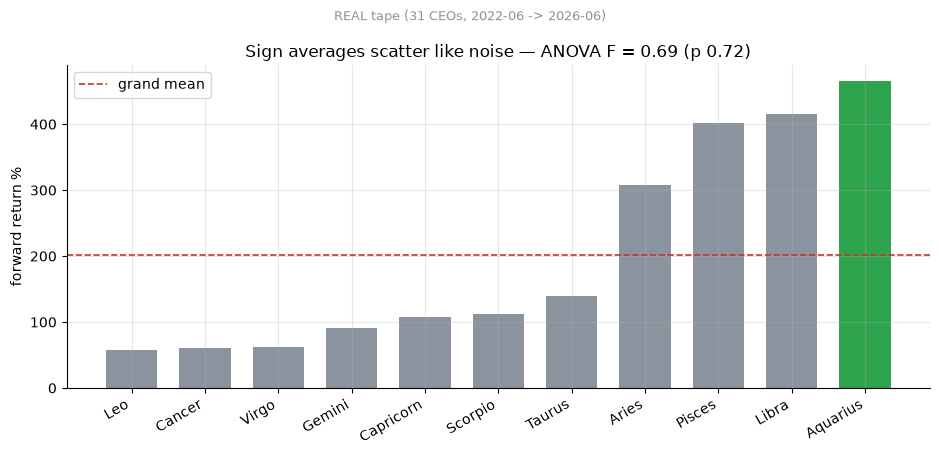

names per sign: {'Aquarius': 3, 'Aries': 3, 'Cancer': 2, 'Capricorn': 3, 'Gemini': 3, 'Leo': 3, 'Libra': 4, 'Pisces': 4, 'Scorpio': 1, 'Taurus': 2, 'Virgo': 3}


In [2]:
if HAVE_REAL:
    means = st.sign_means(PANEL).sort_values()*100
    counts = st.sign_counts(PANEL)
    f = st.anova_f(PANEL); Fval, Fp = f['F'], f['p']
    banner = f'REAL tape ({len(PANEL)} CEOs, 2022-06 -> 2026-06)'
else:
    order = ['Leo','Scorpio','Taurus','Cancer','Libra','Pisces','Capricorn','Gemini','Virgo','Aries','Aquarius']
    means = pd.Series(np.linspace(120, 466.0, len(order)), index=order)
    counts = pd.Series(3, index=order)
    Fval, Fp = 0.69, 0.72
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(9.5, 4.6))
cols = [GREEN if m==means.max() else GREY for m in means]
ax.bar(means.index, means.values, color=cols, width=.7)
ax.axhline(means.mean(), c=RED, ls='--', lw=1.2, label='grand mean')
ax.set_ylabel('forward return %'); ax.legend()
ax.set_title(f'Sign averages scatter like noise — ANOVA F = {Fval:.2f} (p {Fp:.2f})')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print('names per sign:', counts.to_dict())

The bars bounce around, but an **ANOVA F of 0.69** (below 1) means the gaps *between* signs are actually **smaller** than the ordinary scatter *within* each sign. In plain terms: knowing the CEO's star sign tells you nothing about the return. And look at the counts — 2-3 companies per sign. There's no test that could find a signal here even if one existed.

**But wait — one sign *did* have the highest average. Isn't that the lucky sign?** Let's give the folklore its best shot: go long the best sign, short the rest, and then ask a shuffle test how often *random* sign labels would produce a gap that big.

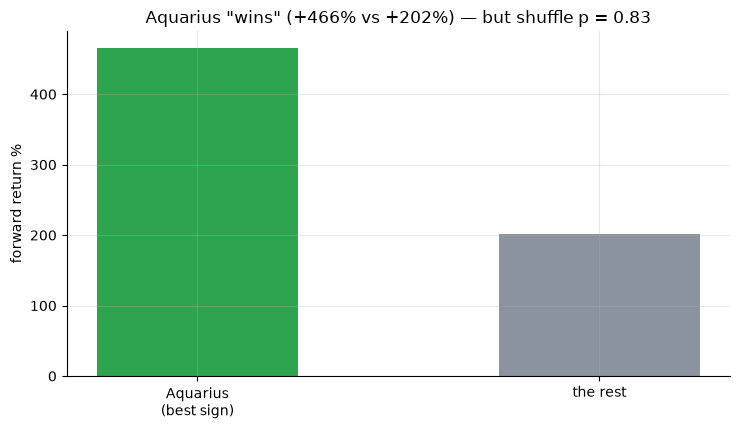

Aquarius: +466% vs rest +202% -> spread +264 pts | shuffle p 0.83


In [3]:
if HAVE_REAL:
    bvr = st.best_vs_rest(PANEL); pl = st.placebo_pvalue(PANEL, n_perm=5000, seed=543)
    best, bm, rm, spr, p = bvr['sign'], bvr['best_mean']*100, bvr['rest_mean']*100, bvr['spread']*100, pl['p_spread']
else:
    best, bm, rm, spr, p = 'Aquarius', 466.0, 202.0, 264.0, 0.83
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar([f'{best}\n(best sign)','the rest'], [bm, rm], color=[GREEN, GREY], width=.5)
ax.set_ylabel('forward return %')
ax.set_title(f'{best} "wins" (+{bm:.0f}% vs +{rm:.0f}%) — but shuffle p = {p:.2f}')
plt.tight_layout(); plt.show()
print(f'{best}: +{bm:.0f}% vs rest +{rm:.0f}% -> spread +{spr:.0f} pts | shuffle p {p:.2f}')

There's the trap. **Aquarius** looks amazing (+466% vs +202%) — but that's because it happens to hold **NVDA**, one stock that ~10x'd in the AI boom. Once you account for the fact that we *cherry-picked the best of twelve signs*, the shuffle test says a gap this big shows up **83% of the time by pure chance**. That's not a signal; that's the definition of luck.

**Does the lucky sign at least stay the same over time?** No — run it over five different windows:

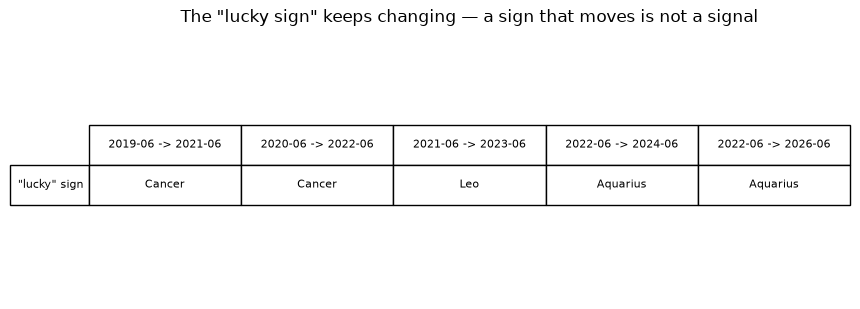

winning sign by window: {'2019-06 -> 2021-06': 'Cancer', '2020-06 -> 2022-06': 'Cancer', '2021-06 -> 2023-06': 'Leo', '2022-06 -> 2024-06': 'Aquarius', '2022-06 -> 2026-06': 'Aquarius'}


In [4]:
wins = [('2019-06 -> 2021-06', 'Cancer'), ('2020-06 -> 2022-06', 'Cancer'), ('2021-06 -> 2023-06', 'Leo'), ('2022-06 -> 2024-06', 'Aquarius'), ('2022-06 -> 2026-06', 'Aquarius')]
labs = [w[0] for w in wins]; best_signs = [w[1] for w in wins]
if HAVE_REAL:
    px = data.fetch_prices(fetch=False)
    spans = [('2019-06-28','2021-06-30'),('2020-06-30','2022-06-30'),
             ('2021-06-30','2023-06-30'),('2022-06-30','2024-06-28'),('2022-06-30','2026-06-26')]
    best_signs = []
    for sp,en in spans:
        pn = data.build_panel(px, sp, en)
        best_signs.append(st.best_vs_rest(pn)['sign'] if not pn.empty else '?')
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis('off')
tbl = ax.table(cellText=[best_signs], colLabels=labs, rowLabels=['"lucky" sign'], loc='center', cellLoc='center')
tbl.scale(1, 2.2); tbl.set_fontsize(11)
ax.set_title('The "lucky sign" keeps changing — a sign that moves is not a signal')
plt.tight_layout(); plt.show()
print('winning sign by window:', dict(zip(labs, best_signs)))

Cancer, Cancer, Leo, Aquarius, Aquarius. The 'lucky sign' is whatever sign happened to hold that window's biggest winner. That's the tell of a coincidence.

## 5 · The verdict

- **Signal — None.** Sign averages scatter like noise (ANOVA F 0.69, shuffle *p* 0.7); the 'best sign' is a cherry-pick that dies at *p* 0.83.
- **Tradability — Mirage.** 2-3 names per sign is a multiple-comparisons mirage; nothing to trade.
- **Lucky sign? — Busted.** The winner changes every window and rides one mega-cap.

## 6 · Could you actually trade it?

No. Even ignoring that there's no real gap, the 'trade' would be long one sign and short the other eleven — on 2-3 stocks per bucket, rebuilt whenever a CEO changes. The apparent edge is one AI winner sitting in one sign. Costs are a footnote to a number that is already luck.

## 7 · Going further 🚪

- **The calendar cousin.** [165 Chinese-Zodiac](../../165-chinese-zodiac/) tests the zodiac *year* (Dragon-year bullishness) and busts it the same way — small-sample, multiple-comparisons.
- **Why it can never be 'Real'.** A sun sign never changes over a CEO's tenure, so there's no time series to average — just one thin cross-section. No amount of data-mining can turn a birthday into alpha.

*Think there's a lucky sign? Fork this, add hundreds of CEOs (so each sign has real power), and show one sign's ANOVA clearing significance after a multiple-comparisons correction. Spoiler: it won't.*